In [1]:
import ee
import pandas as pd
import matplotlib.pyplot as plt

ee.Initialize()

counties = ee.FeatureCollection("FAO/GAUL/2015/level2")

makueni = counties.filter(
    ee.Filter.And(
        ee.Filter.eq("ADM0_NAME", "Kenya"),
        ee.Filter.eq("ADM2_NAME", "Makueni")
    )
)

In [2]:
chirps = ee.ImageCollection(
    "UCSB-CHG/CHIRPS/DAILY"
)

In [6]:
months = pd.date_range(
    start="2023-01-01",
    end="2024-12-01",
    freq="MS"
)

months

DatetimeIndex(['2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01',
               '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[us]', freq='MS')

In [3]:
def monthly_rainfall(start_date, end_date):

    rain = (
        ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
        .filterBounds(makueni)
        .filterDate(start_date, end_date)
        .sum()
    )

    rainfall = rain.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=makueni.geometry(),
        scale=5000,
        maxPixels=1e9
    )

    return rainfall.get("precipitation")

In [4]:
print(
    monthly_rainfall(
        "2024-01-01",
        "2024-02-01"
    ).getInfo()
)

63.01005929571195


In [7]:
results = []

for start in months:
    end = start + pd.DateOffset(months=1)

    value = monthly_rainfall(
        start.strftime("%Y-%m-%d"),
        end.strftime("%Y-%m-%d")
    ).getInfo()

    results.append({
        "month": start,
        "rainfall_mm": value
    })

In [9]:
rain_df = pd.DataFrame(results)
rain_df

,month,rainfall_mm
0,2023-01-01,14.535096
1,2023-02-01,3.766772
2,2023-03-01,61.026191
3,2023-04-01,165.047111
4,2023-05-01,33.181699
5,2023-06-01,7.374644
6,2023-07-01,6.383287
7,2023-08-01,5.165026
8,2023-09-01,3.704895
9,2023-10-01,42.187587


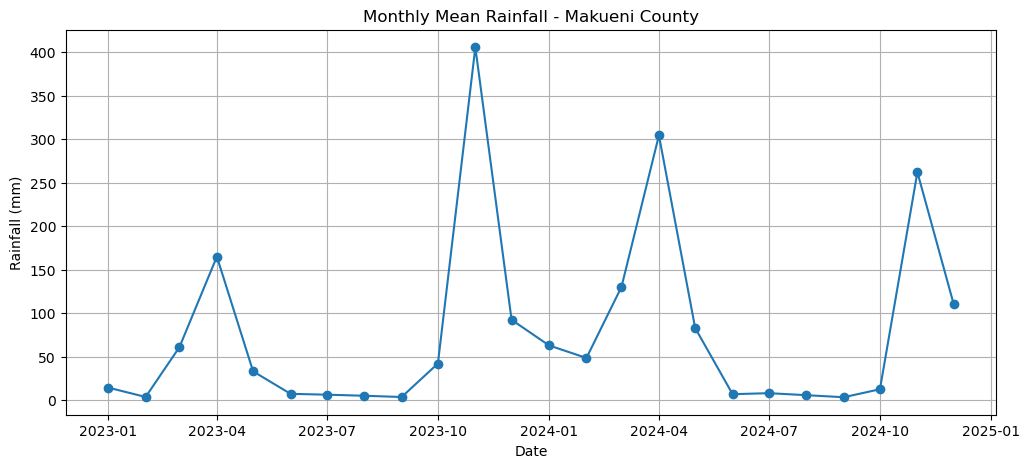

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(rain_df["month"], rain_df["rainfall_mm"], marker="o")
plt.title("Monthly Mean Rainfall - Makueni County")
plt.ylabel("Rainfall (mm)")
plt.xlabel("Date")
plt.grid(True)

plt.savefig(
    "../docs/images/makueni_rainfall_timeseries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
rain_df.to_csv(
    "../outputs/makueni_monthly_rainfall_2023_2024.csv",
    index=False
)